In [1]:
import cv2
import dlib
import numpy as np
from imutils import face_utils

In [2]:
def smooth_sequence(values, window_size=5):
    kernel = np.ones(window_size) / window_size
    return np.convolve(values, kernel, mode='valid')

In [3]:
import pandas as pd
labels_df = pd.read_csv("../recordings_log.csv")  # Update with your actual filename
labels_df.columns = labels_df.columns.str.strip().str.replace(" ", "_")
labels_df.head()
labels_df = labels_df.dropna(subset=["Outcome"])

In [4]:
# Load dlib's models
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

In [5]:
import os
import cv2
import numpy as np
from imutils import face_utils

# Setup dlib detector + predictor
import dlib
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

landmark_data = []
frame_interval = 15  # Sample every 30 frames

for _, row in labels_df.iterrows():
    video_file = "../" + row["Video_Filename"].replace("\\", "/")
    label = int(row["Outcome"])
    video_name = video_file.split("/")[-1]

    if not os.path.exists(video_file):
        print(f"❌ File not found: {video_file}")
        continue

    cap = cv2.VideoCapture(video_file)
    frame_count = 0
    successful_faces = 0

    sampled_landmarks = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1
        if frame_count % frame_interval != 0:
            continue

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype("uint8")
        faces = detector(gray)

        if len(faces) == 0:
            print(f"⚠️ No faces detected — {video_name}, frame {frame_count}")
            continue

        for rect in faces:
            shape = predictor(gray, rect)
            shape_np = face_utils.shape_to_np(shape)  # shape: (68, 2)
            sampled_landmarks.append(shape_np)  # save for movement tracking

            vector = shape_np.flatten()
            landmark_data.append({
                "Video_Filename": video_name,
                "frame": frame_count,
                "label": label,
                **{f"pt_{i}": val for i, val in enumerate(vector)}
            })
            successful_faces += 1

    cap.release()

    motion_total = 0
    motion_sequence = []

    for i in range(len(sampled_landmarks) - 1):
        delta = np.linalg.norm(sampled_landmarks[i+1] - sampled_landmarks[i], axis=1)
        frame_motion = delta.sum()
        motion_sequence.append(frame_motion)
        motion_total += frame_motion

    smoothed_motion = motion_sequence.copy()
    if len(motion_sequence) >= 3:
        kernel = np.ones(3) / 3
        smoothed_motion = np.convolve(motion_sequence, kernel, mode="valid")


    avg_motion = motion_total / (len(sampled_landmarks) - 1) if len(sampled_landmarks) > 1 else 0
    smoothed_avg_motion = np.mean(smoothed_motion) if len(smoothed_motion) > 0 else avg_motion
    

    landmark_data.append({
        "Video_Filename": video_name,
        "frame": "summary",
        "label": label,
        "movement_intensity": smoothed_avg_motion
    })


    print(f"✅ Processed {video_name}, faces extracted: {successful_faces}, avg motion: {avg_motion:.2f}, smooth: {smoothed_avg_motion:.2f}")


✅ Processed clip_20250722_124710.avi, faces extracted: 13, avg motion: 1215.14, smooth: 1230.70
✅ Processed clip_20250722_124740.avi, faces extracted: 8, avg motion: 703.84, smooth: 716.99
✅ Processed clip_20250722_124811.avi, faces extracted: 12, avg motion: 322.22, smooth: 325.17
✅ Processed clip_20250722_124825.avi, faces extracted: 10, avg motion: 463.51, smooth: 419.94
✅ Processed clip_20250722_124846.avi, faces extracted: 13, avg motion: 613.58, smooth: 630.62
✅ Processed clip_20250722_124908.avi, faces extracted: 9, avg motion: 525.63, smooth: 498.79
✅ Processed clip_20250722_124927.avi, faces extracted: 14, avg motion: 688.05, smooth: 475.15
✅ Processed clip_20250722_125014.avi, faces extracted: 10, avg motion: 533.11, smooth: 492.42
✅ Processed clip_20250722_125035.avi, faces extracted: 13, avg motion: 654.08, smooth: 677.72
✅ Processed clip_20250722_125124.avi, faces extracted: 10, avg motion: 716.79, smooth: 710.86
✅ Processed clip_20250722_125144.avi, faces extracted: 11, a

In [6]:
import numpy as np
import pandas as pd

def normalize_landmarks(row):
    coords = np.array([row[f"pt_{i}"] for i in range(136)], dtype=np.float64).reshape(-1, 2)

    # Step 1: Center the face on nose tip
    nose_tip = coords[30]
    coords -= nose_tip

    # Step 2: Scale by interocular distance
    left_eye = coords[36]
    right_eye = coords[45]
    eye_dist = np.linalg.norm(right_eye - left_eye)
    coords /= eye_dist if eye_dist != 0 else 1

    # Step 3: Rotate so eyes are horizontally aligned
    eye_vector = right_eye - left_eye
    angle = -np.arctan2(eye_vector[1], eye_vector[0])
    rotation_matrix = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])
    coords = coords @ rotation_matrix.T

    return coords.flatten()

# Load raw landmark data
df_landmarks = pd.DataFrame(landmark_data)

# 🔍 Step 1: Extract movement_intensity per clip from summary rows
df_movement = df_landmarks[df_landmarks["frame"] == "summary"][["Video_Filename", "movement_intensity"]]

# Drop summary rows before normalization
df_frames = df_landmarks[df_landmarks["frame"] != "summary"].copy()

# Normalize all landmark rows
normalized = df_frames.apply(normalize_landmarks, axis=1, result_type="expand")
normalized.columns = [f"norm_pt_{i}" for i in range(136)]

# Combine normalized landmarks + clip info
df_normalized = pd.concat([df_frames[["Video_Filename", "frame", "label"]], normalized], axis=1)

# Merge movement intensity onto each frame row by video name
df_normalized = df_normalized.merge(df_movement, on="Video_Filename", how="left")

# ✅ Save final dataset
df_normalized.to_csv("normalized_landmark_data_with_motion.csv", index=False)
print(f"✅ Saved {len(df_normalized)} normalized samples with motion intensity.")


✅ Saved 2860 normalized samples with motion intensity.


In [7]:
df_landmarks = pd.DataFrame(landmark_data)
df_landmarks.to_csv("normalized_landmark_data.csv", index=False)

print(f"✅ Saved {len(df_landmarks)} samples from {len(labels_df)} video clips.")

✅ Saved 2622 samples from 256 video clips.


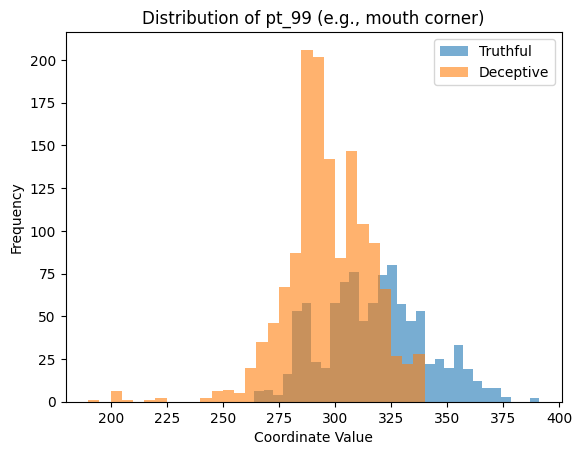

In [8]:
import matplotlib.pyplot as plt

# Choose a landmark index (e.g., pt_48/54 = mouth corner, 36/45 out corner of eyes 30 nose tip)
landmark_index = 99
truthful = df_landmarks[df_landmarks["label"] == 0][f"pt_{landmark_index}"]
deceptive = df_landmarks[df_landmarks["label"] == 1][f"pt_{landmark_index}"]

plt.hist(truthful, bins=30, alpha=0.6, label="Truthful")
plt.hist(deceptive, bins=30, alpha=0.6, label="Deceptive")
plt.title(f"Distribution of pt_{landmark_index} (e.g., mouth corner)")
plt.xlabel("Coordinate Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()


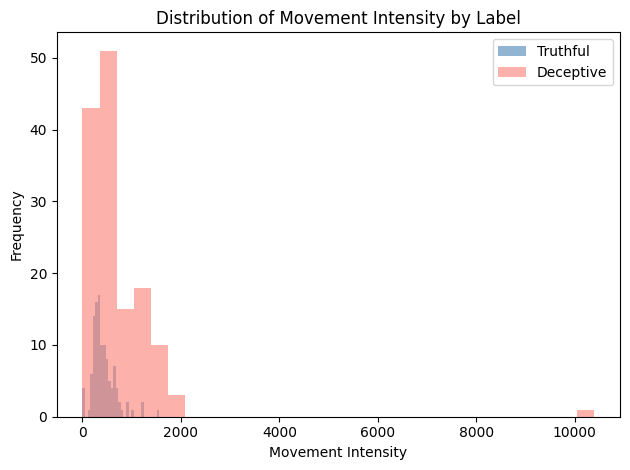

In [9]:
import matplotlib.pyplot as plt

truthful_motion = df_landmarks[(df_landmarks["frame"] == "summary") & (df_landmarks["label"] == 0)]["movement_intensity"]
deceptive_motion = df_landmarks[(df_landmarks["frame"] == "summary") & (df_landmarks["label"] == 1)]["movement_intensity"]

plt.hist(truthful_motion, bins=30, alpha=0.6, label="Truthful", color="steelblue")
plt.hist(deceptive_motion, bins=30, alpha=0.6, label="Deceptive", color="salmon")
plt.title("Distribution of Movement Intensity by Label")
plt.xlabel("Movement Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


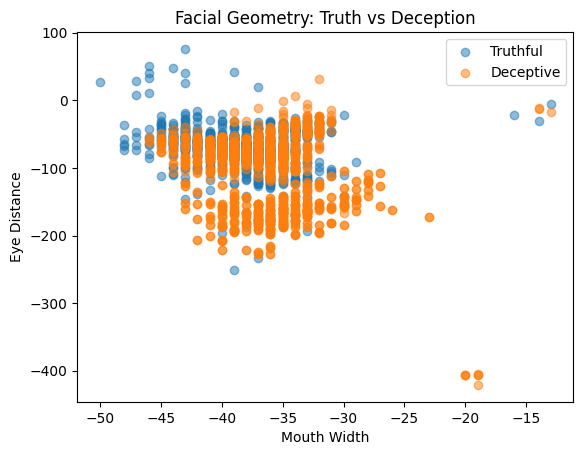

In [10]:
x = df_landmarks["pt_54"] - df_landmarks["pt_48"]  # mouth width
y = df_landmarks["pt_45"] - df_landmarks["pt_36"]  # eye distance

plt.scatter(x[df_landmarks["label"] == 0], y[df_landmarks["label"] == 0], alpha=0.5, label="Truthful")
plt.scatter(x[df_landmarks["label"] == 1], y[df_landmarks["label"] == 1], alpha=0.5, label="Deceptive")
plt.xlabel("Mouth Width")
plt.ylabel("Eye Distance")
plt.title("Facial Geometry: Truth vs Deception")
plt.legend()
plt.show()


In [11]:
import numpy as np

truth_avg = df_landmarks[df_landmarks["label"] == 0].iloc[:, 3:].mean().values.reshape(-1, 2)
lie_avg = df_landmarks[df_landmarks["label"] == 1].iloc[:, 3:].mean().values.reshape(-1, 2)

plt.scatter(truth_avg[:, 0], truth_avg[:, 1], label="Truthful", alpha=0.7)
plt.scatter(lie_avg[:, 0], lie_avg[:, 1], label="Deceptive", alpha=0.7)
plt.gca().invert_yaxis()
plt.title("Average Facial Landmarks by Class")
plt.legend()
plt.show()


ValueError: cannot reshape array of size 137 into shape (2)

C:\Users\connellj2\AppData\Local\Temp\ipykernel_17832\2936877565.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_normalized["label"], y=df_normalized["movement_intensity"], palette="Set2")


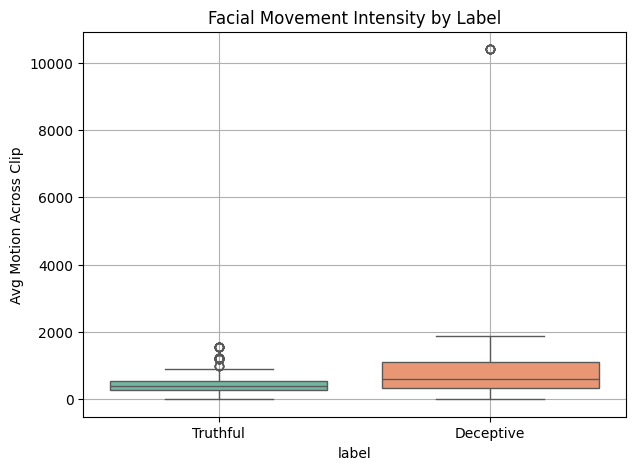

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.boxplot(x=df_normalized["label"], y=df_normalized["movement_intensity"], palette="Set2")
plt.xticks([0,1], ["Truthful", "Deceptive"])
plt.title("Facial Movement Intensity by Label")
plt.ylabel("Avg Motion Across Clip")
plt.grid(True)
plt.show()


In [21]:
# Path to video file
video_path = "C:/Users/connellj2/OneDrive - Wentworth Institute of Technology/Documents/DecepTech/CroppedClips/clip_20250721_133055.avi"

# Initialize video capture
cap = cv2.VideoCapture(video_path)

# Storage for extracted vectors
landmark_vectors = []

# Sampling parameters
frame_interval = 30
frame_count = 0


In [22]:
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    if frame_count % frame_interval != 0:
        continue

    # Convert to grayscale and ensure format
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = gray.astype('uint8')

    # Detect faces and extract landmarks
    faces = detector(gray)
    for rect in faces:
        shape = predictor(gray, rect)
        shape_np = face_utils.shape_to_np(shape)
        vector = shape_np.flatten()
        landmark_vectors.append({
            "frame": frame_count,
            "landmarks": vector.tolist()
        })

print(f"✅ Extracted {len(landmark_vectors)} landmark vectors.")

cap.release()


✅ Extracted 0 landmark vectors.


In [23]:
import pandas as pd

# Flatten the data into rows with frame ID + 136 landmarks
rows = []
for item in landmark_vectors:
    row = {"frame": item["frame"]}
    for i, val in enumerate(item["landmarks"]):
        row[f"pt_{i}"] = val
    rows.append(row)

# Create DataFrame and export
df = pd.DataFrame(rows)
df.to_csv("landmark_vectors_sampled.csv", index=False)

print("✅ Landmark vectors saved to landmark_vectors_sampled.csv")


✅ Landmark vectors saved to landmark_vectors_sampled.csv


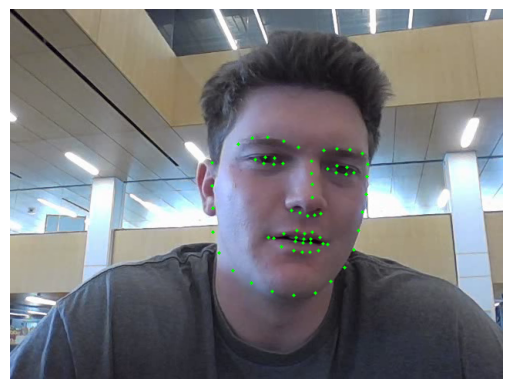

<Figure size 640x480 with 0 Axes>

In [2]:
import cv2
import dlib
from imutils import face_utils
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# Load dlib's face detector and shape predictor
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# Load your video file
video_path = "C:/Users/connellj2/OneDrive - Wentworth Institute of Technology/Documents/DecepTech/CroppedClips/clip_20250721_133055.avi"
cap = cv2.VideoCapture(video_path)

frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame_count > 100:  # Limit frames for testing
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = gray.astype('uint8')
    faces = detector(gray)

    for rect in faces:
        shape = predictor(gray, rect)
        shape_np = face_utils.shape_to_np(shape)

        for (x, y) in shape_np:
            cv2.circle(frame, (x, y), 2, (0, 255, 0), -1)

    # Convert BGR to RGB for display
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(rgb_frame)
    plt.axis('off')
    clear_output(wait=True)
    display(plt.gcf())
    plt.clf()

    frame_count += 1

cap.release()
